In [1]:
import pickle
import pandas as pd
from pandas import Series
from tqdm import tqdm
import seaborn as sns
import numpy as np

import matplotlib
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
from matplotlib import rc

from sklearn.preprocessing import normalize
from sklearn.linear_model import LinearRegression

import requests

In [2]:
import matplotlib.pyplot as plt 

In [3]:
base_path= './'

df = pd.read_csv(base_path+'words/vocas_counting.csv')
df_idx = pd.read_csv(base_path+'words/vocas.csv')
df_norm = pd.DataFrame(normalize(df, norm='l1', axis=0), columns=[int(x) for x in df.columns])

idx2word = dict(zip(df_idx['index'], df_idx['word']))
wordidx2cnt = df.sum(axis=1)
wordidx2cnt = wordidx2cnt.sort_values(ascending=0)
word2idx = {v:k for k,v in idx2word.items()}

In [4]:
words_a = ['jesus','angel','saint']
words_b = ['man','woman','people']
words_c = ['portrait','abstract']
words_d = ['mountain','river','trees']
words_e = ['train','ship']
words_f = ['blue','red','green']

words_zip = [words_a, words_b, words_c, words_d, words_e, words_f]

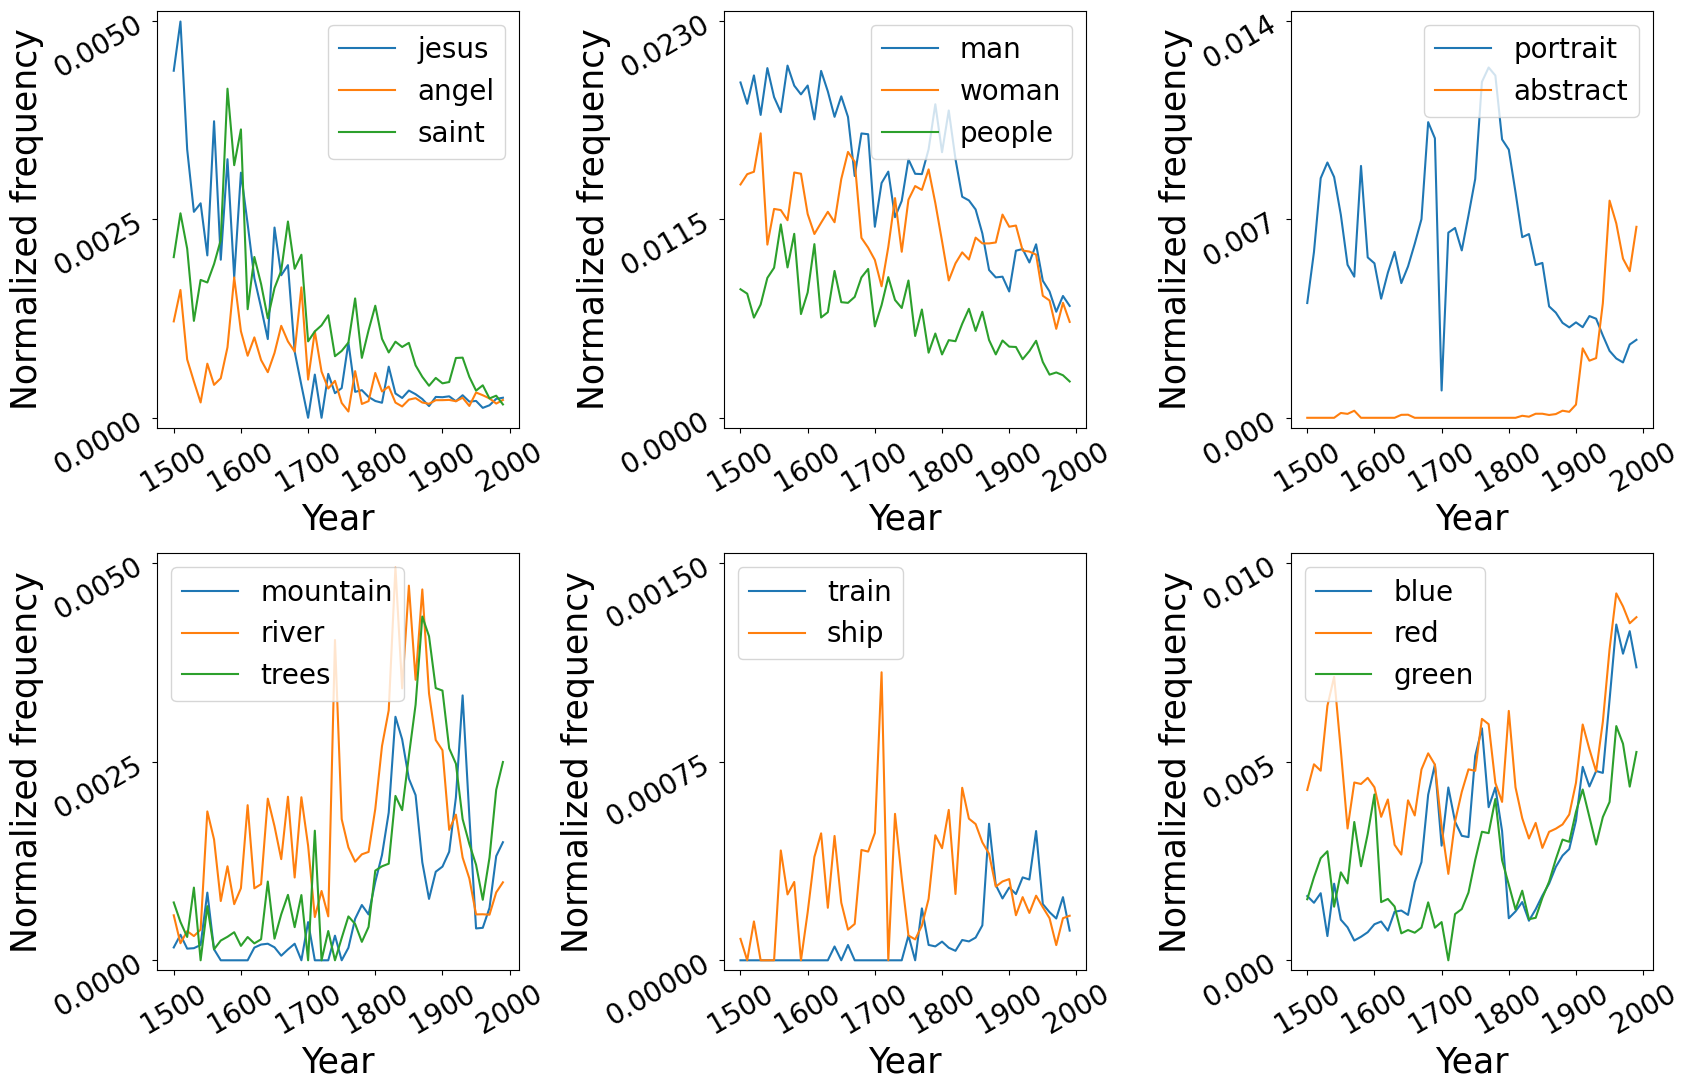

In [5]:
import numpy as np
import matplotlib.ticker as ticker

fig, ax = plt.subplots(2, 3, figsize=(17, 11))
ax = ax.reshape(-1)

lims = [[0.00,0.05,0.10],[0.00,0.23,0.46],[0.00,0.14,0.28],[0.00,0.05,0.10],[0.00,0.015,0.03],[0.00,0.10,0.20]]
lims = [np.array(i)*0.05 for i in lims]

for idx, words in enumerate(words_zip):
    for i, word in enumerate(words):
        ax[idx].plot(df_norm[df_norm.columns.difference(['slope', 'word'])].loc[word2idx[word]], label=f'{word}')
    if idx in [0,1,2] :
        ax[idx].legend(bbox_to_anchor=(1, 1), fontsize=20, loc="upper right")
    else :
        ax[idx].legend(bbox_to_anchor=(0, 1), fontsize=20, loc="upper left")
    ax[idx].set_xlabel('Year', fontsize=25)
    ax[idx].set_ylabel('Normalized frequency', fontsize=25)

    # Set 5 y-ticks between the min and max values
    ax[idx].set_yticks(lims[idx])  # Set 5 evenly spaced ticks


    # Format y-ticks to 2 decimal places
    #ax[idx].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))
    r = lims[idx][2]-lims[idx][0]
    ax[idx].set_ylim(lims[idx][0]-r*0.025,lims[idx][2]+r*0.025)

    # Ensure all x-ticks are shown
    ax[idx].set_xticks([1500+i*100 for i in range(6)])  # Set all x-ticks

    # Set tick label sizes
    ax[idx].tick_params(axis='x', labelsize=20, rotation=30)
    ax[idx].tick_params(axis='y', labelsize=20, rotation=30)


plt.tight_layout()  # Ensure that subplots do not overlap
#plt.savefig('/home/jinny/projects/Art-history/Art-history/graph/figure03.svg',bbox_inches='tight',transparent = True,dpi=600)
plt.show()


In [6]:
from itertools import chain
flat_wordlist = ','.join(chain.from_iterable(words_zip))
print(flat_wordlist)

jesus,angel,saint,man,woman,people,portrait,abstract,mountain,river,trees,train,ship,blue,red,green


In [7]:
df = pd.read_csv("./ngram_selected_words.csv")

In [8]:
df['decade'] = (df['year'] // 10) * 10

In [9]:
df_mean_freq_decade = df.groupby(['ngram', 'decade'])['frequency'].mean().reset_index()
df_mean_freq_decade = df_mean_freq_decade[df_mean_freq_decade["decade"] <= 2000]

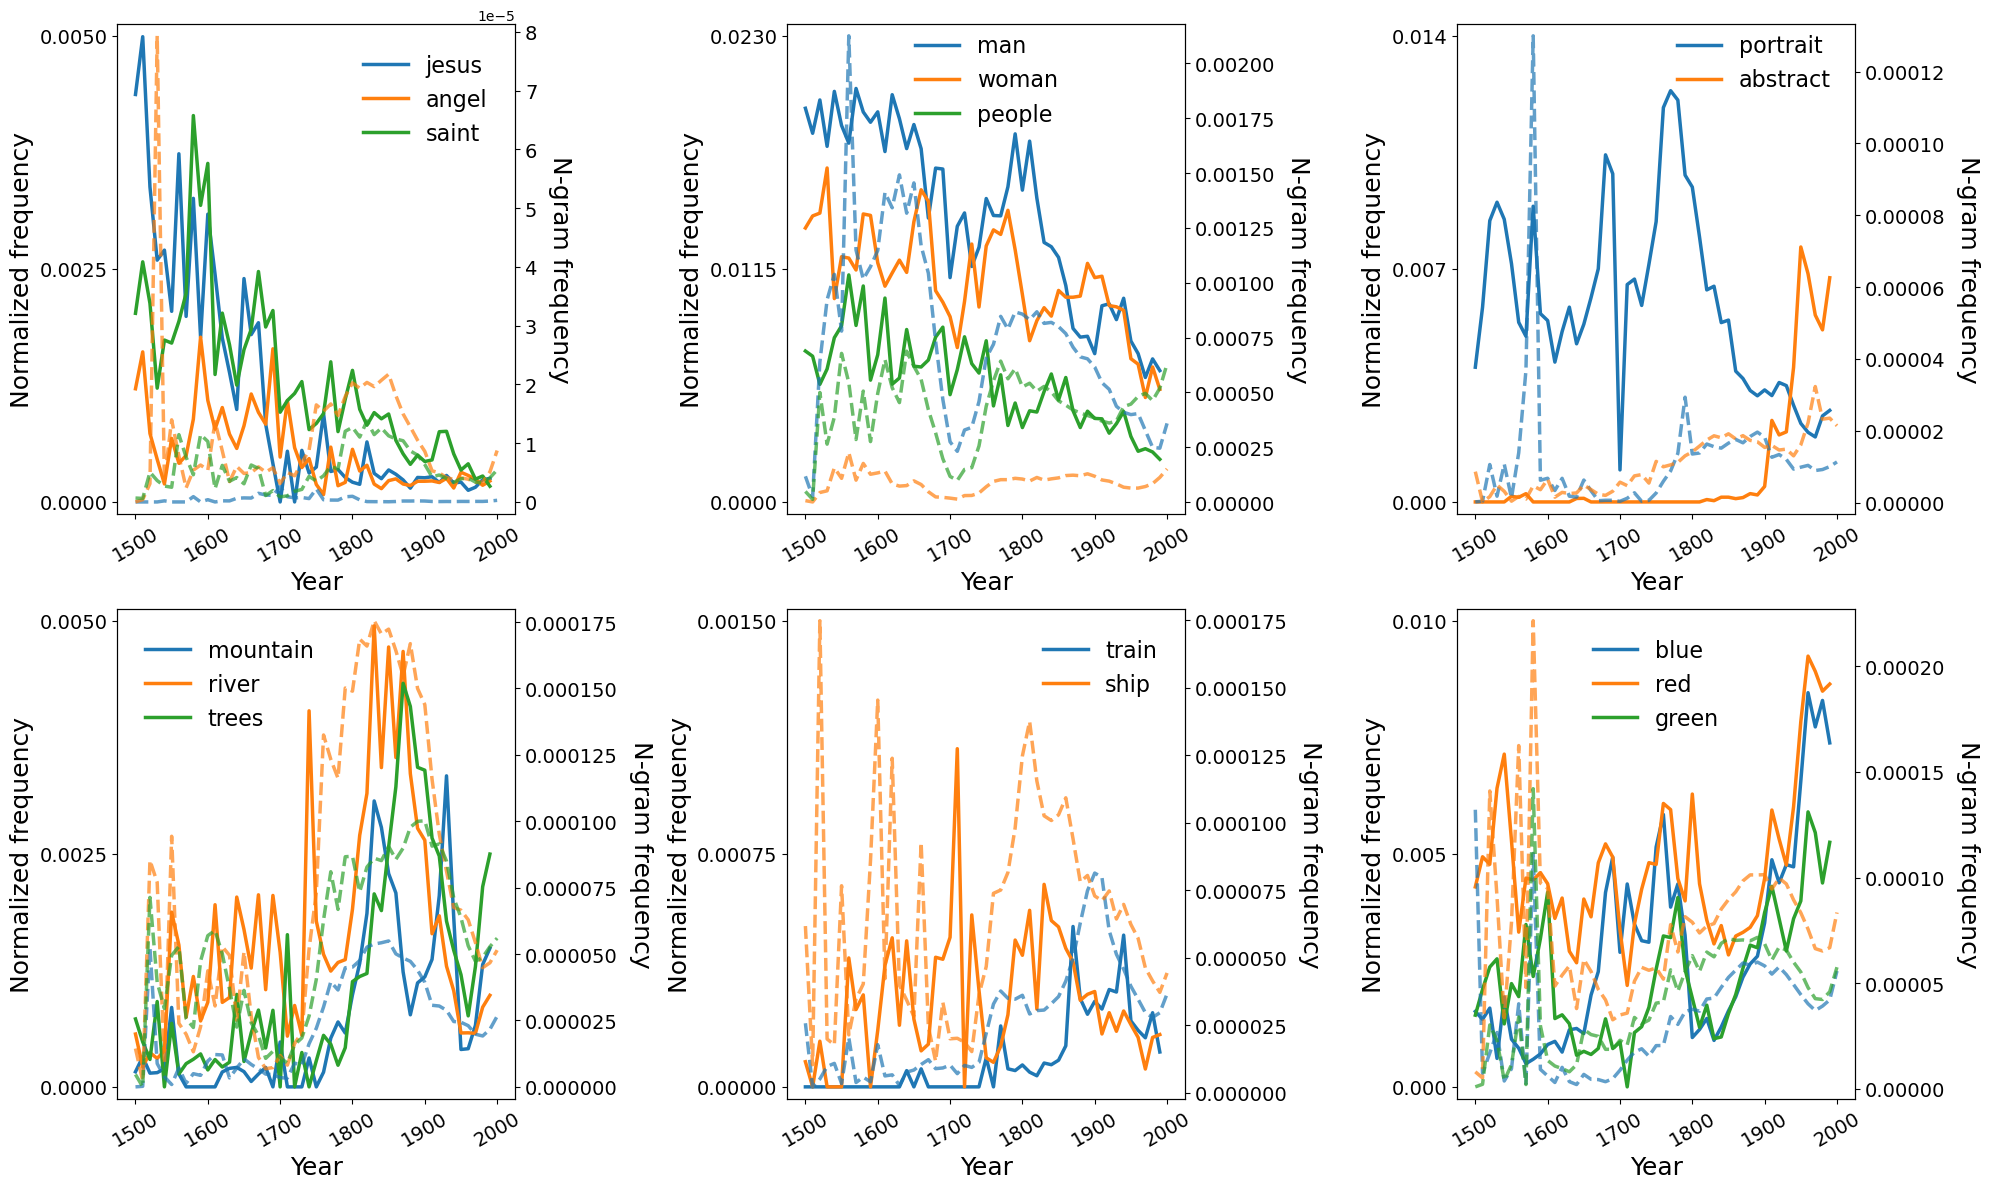

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(2, 3, figsize=(20, 12))
ax = ax.reshape(-1)
lims = [[0.00,0.05,0.10],[0.00,0.23,0.46],[0.00,0.14,0.28],[0.00,0.05,0.10],[0.00,0.015,0.03],[0.00,0.10,0.20]]
lims = [np.array(i)*0.05 for i in lims]

for idx, words in enumerate(words_zip):
    # 두 번째 y축 생성
    ax2 = ax[idx].twinx()
    
    # Matplotlib 기본 색상 (C0, C1, C2, ...)
    colors = [f'C{i}' for i in range(len(words))]
    
    for i, word in enumerate(words):
        color = colors[i]
        
        # 원본 데이터 (실선)
        ax[idx].plot(df_norm[df_norm.columns.difference(['slope', 'word'])].loc[word2idx[word]], 
                     label=f'{word}', 
                     color=color, 
                     linestyle='-',
                     linewidth=2.5)
        
        # n-gram 데이터 (파선)
        ngram_data = df_mean_freq_decade[df_mean_freq_decade['ngram'] == word]
        if not ngram_data.empty:
            ax2.plot(ngram_data['decade'], 
                    ngram_data['frequency'], 
                    color=color, 
                    linestyle='--',
                    linewidth=2.5,
                    alpha=0.7)
    
    # 범례 위치를 subplot별로 다르게 설정
    if idx == 0:  # jesus, angel, saint - 우측 상단
        ax[idx].legend(loc='upper right', bbox_to_anchor=(0.98, 0.98),
                       fontsize=16, frameon=False)
    elif idx == 1:  # man, woman, people - 상단 가운데 (더 위로)
        ax[idx].legend(loc='upper center', bbox_to_anchor=(0.5, 1.02),
                       fontsize=16, frameon=False)
    elif idx == 2:  # portrait, abstract - 우측 상단 (더 위로)
        ax[idx].legend(loc='upper right', bbox_to_anchor=(0.99, 1.02),
                       fontsize=16, frameon=False)
    elif idx == 3:  # mountain, river, trees - 좌측 상단
        ax[idx].legend(loc='upper left', bbox_to_anchor=(0.02, 0.98),
                       fontsize=16, frameon=False)
    elif idx == 4:  # train, ship - 우측 상단
        ax[idx].legend(loc='upper right', bbox_to_anchor=(0.98, 0.98),
                       fontsize=16, frameon=False)
    elif idx == 5:  # blue, red, green - 상단 가운데
        ax[idx].legend(loc='upper center', bbox_to_anchor=(0.5, 0.98),
                       fontsize=16, frameon=False)
    
    # 왼쪽 y축 설정 (원본 데이터)
    ax[idx].set_xlabel('Year', fontsize=18)
    ax[idx].set_ylabel('Normalized frequency', fontsize=18)
    ax[idx].set_yticks(lims[idx])
    r = lims[idx][2]-lims[idx][0]
    ax[idx].set_ylim(lims[idx][0]-r*0.025, lims[idx][2]+r*0.025)
    
    # 오른쪽 y축 설정 (n-gram 데이터)
    ax2.set_ylabel('N-gram frequency', fontsize=18, rotation=270, labelpad=25)
    
    # n-gram 데이터의 min/max 기준으로 y축 설정
    ngram_subset = df_mean_freq_decade[df_mean_freq_decade['ngram'].isin(words)]
    if not ngram_subset.empty:
        ngram_min = ngram_subset['frequency'].min()
        ngram_max = ngram_subset['frequency'].max()
        ngram_range = ngram_max - ngram_min
        ax2.set_ylim(ngram_min - ngram_range*0.025, ngram_max + ngram_range*0.025)
    
    # x축 설정
    ax[idx].set_xticks([1500+i*100 for i in range(6)])
    ax[idx].tick_params(axis='x', labelsize=14, rotation=30)
    ax[idx].tick_params(axis='y', labelsize=14)
    ax2.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.savefig("./Fig03_with_ngram.png", dpi=300)
plt.savefig("./Fig03_with_ngram.pdf")

plt.show()

In [11]:
df_list = []
for word in flat_wordlist.split(","):
    df_temp = pd.DataFrame(df_norm[df_norm.columns.difference(['slope', 'word'])].loc[word2idx[word]])
    df_temp['word'] = word
    df_temp = df_temp.reset_index()
    df_temp.columns = ["Year","Freq","ngram"]
    df_list.append(df_temp)

In [12]:
df_mean_freq_decade

,ngram,decade,frequency
0,abstract,1500,8.632096e-06
1,abstract,1510,1.999628e-07
2,abstract,1520,1.678879e-06
3,abstract,1530,4.926219e-06
4,abstract,1540,3.145049e-06
...,...,...,...
826,woman,1960,6.390761e-05
827,woman,1970,7.111503e-05
828,woman,1980,8.425373e-05
829,woman,1990,1.126306e-04


In [13]:
df_freq = pd.concat(df_list).reset_index()

In [14]:
df_freq

,index,Year,Freq,ngram
0,0,1500,0.004371,jesus
1,1,1510,0.004990,jesus
2,2,1520,0.003379,jesus
3,3,1530,0.002594,jesus
4,4,1540,0.002701,jesus
...,...,...,...,...
795,45,1950,0.003988,green
796,46,1960,0.005899,green
797,47,1970,0.005454,green
798,48,1980,0.004374,green


In [15]:
df_freq_merged = df_freq.merge(df_mean_freq_decade, left_on=["ngram", "Year"], right_on=["ngram", "decade"], how="inner")

In [16]:
df_freq_merged

,index,Year,Freq,ngram,decade,frequency
0,0,1500,0.004371,jesus,1500,0.000000e+00
1,1,1510,0.004990,jesus,1510,0.000000e+00
2,2,1520,0.003379,jesus,1520,0.000000e+00
3,3,1530,0.002594,jesus,1530,0.000000e+00
4,4,1540,0.002701,jesus,1540,1.875441e-07
...,...,...,...,...,...,...
795,45,1950,0.003988,green,1950,5.531163e-05
796,46,1960,0.005899,green,1960,4.795665e-05
797,47,1970,0.005454,green,1970,4.272747e-05
798,48,1980,0.004374,green,1980,4.232808e-05


In [17]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# 단어별로 그룹화하여 상관계수 계산
correlations = []

for word in df['ngram'].unique():
    word_data = df_freq_merged[df_freq_merged['ngram'] == word].copy()
    
    # decade 기준으로 정렬
    word_data = word_data.sort_values('decade')
    
    # Pearson 상관계수
    pearson_corr, pearson_pval = pearsonr(word_data['Freq'], word_data['frequency'])
    
    # Spearman 상관계수 (순위 기반)
    spearman_corr, spearman_pval = spearmanr(word_data['Freq'], word_data['frequency'])
    
    correlations.append({
        'word': word,
        'pearson_corr': pearson_corr,
        'pearson_pval': pearson_pval,
        'spearman_corr': spearman_corr,
        'spearman_pval': spearman_pval,
        'n_points': len(word_data)
    })

corr_df = pd.DataFrame(correlations)
corr_df = corr_df.sort_values('pearson_corr', ascending=False)

corr_df

,word,pearson_corr,pearson_pval,spearman_corr,spearman_pval,n_points
11,train,0.775411,3.805873e-11,0.850043,5.779838e-15,50
9,river,0.677438,6.557110e-08,0.581273,9.583756e-06,50
8,mountain,0.671576,9.362818e-08,0.659858,1.864295e-07,50
10,trees,0.645353,4.199026e-07,0.579059,1.055324e-05,50
7,abstract,0.600501,4.025288e-06,0.576713,1.167859e-05,50
3,man,0.553645,3.038967e-05,0.598752,4.366000e-06,50
15,green,0.266960,6.091375e-02,0.337143,1.665561e-02,50
12,ship,0.105868,4.643371e-01,0.194305,1.763369e-01,50
13,blue,0.099801,4.904628e-01,0.241200,9.152227e-02,50
6,portrait,0.091017,5.295983e-01,-0.156110,2.789852e-01,50


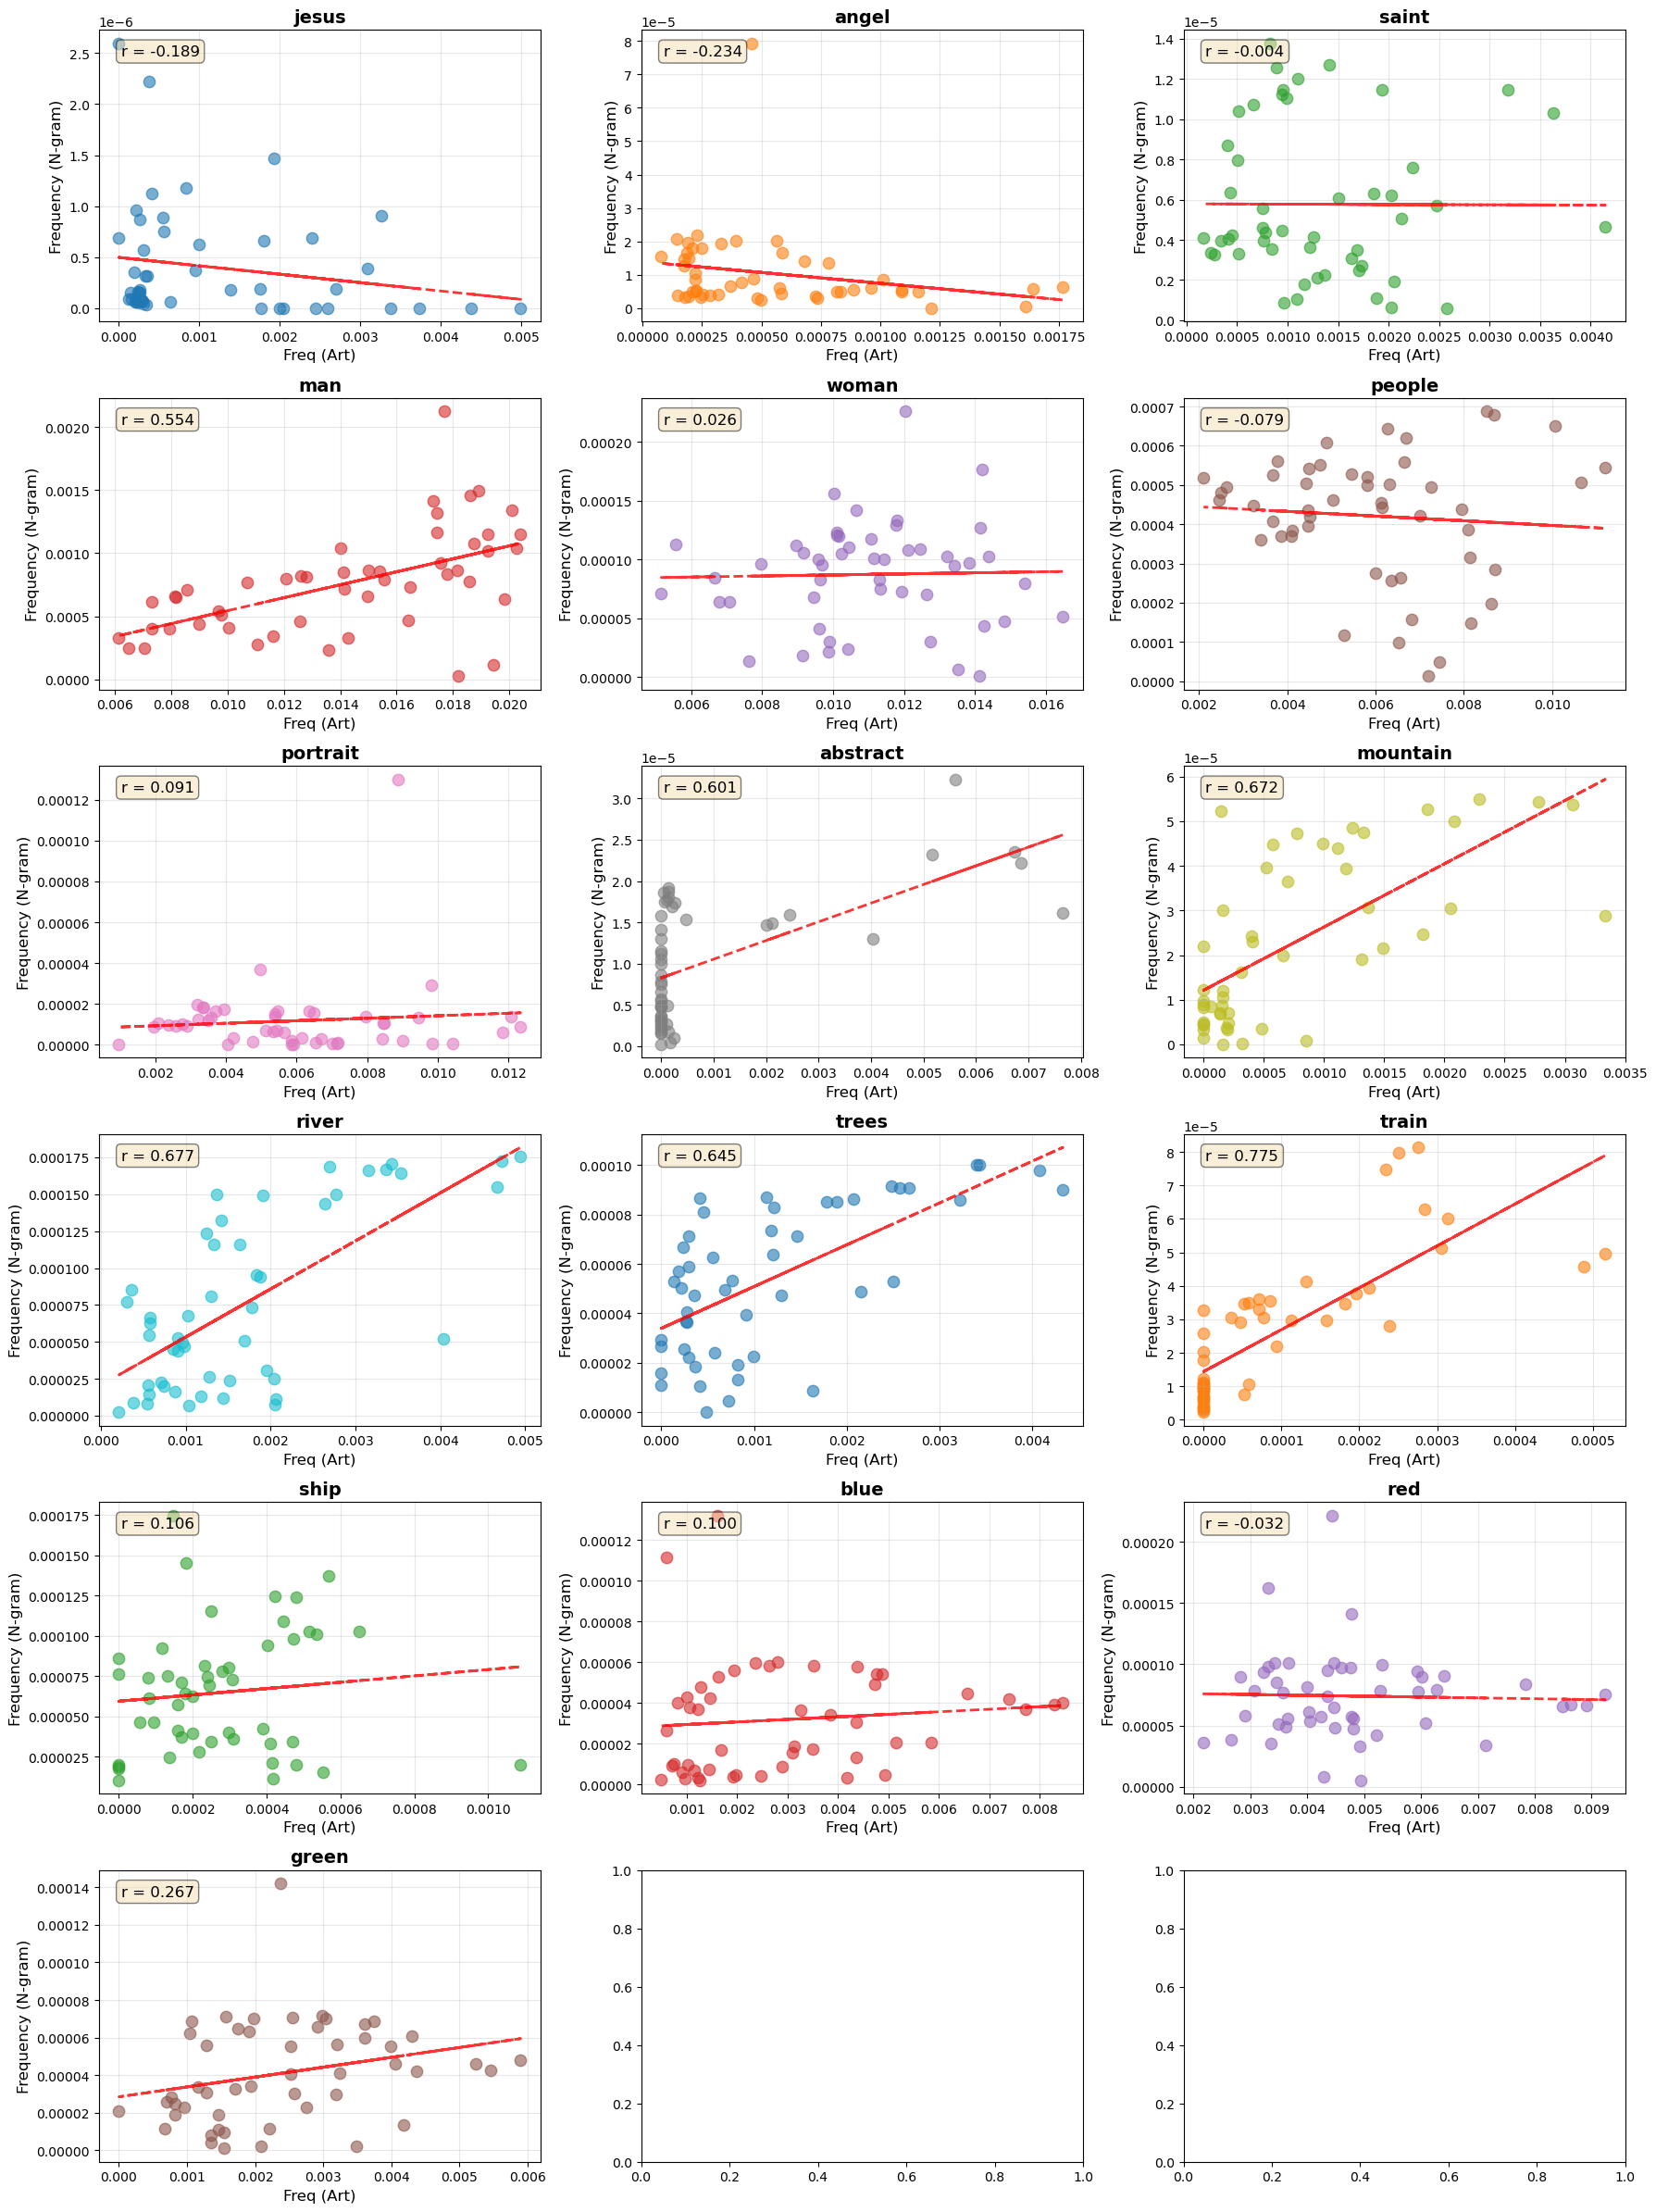

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 모든 단어 가져오기
all_words = df['ngram'].unique()

# 그리드 설정 (6x3 = 18개)
fig, axes = plt.subplots(6, 3, figsize=(18, 24))
axes = axes.reshape(-1)

for idx, word in enumerate(all_words):
    word_data = df_freq_merged[df_freq_merged['ngram'] == word].copy()
    word_data = word_data.sort_values('decade')
    
    ax = axes[idx]
    
    # Scatter plot
    ax.scatter(word_data['Freq'], word_data['frequency'], 
               alpha=0.6, s=80, color=f'C{idx % 10}')
    
    # 추세선 추가 (선택사항)
    z = np.polyfit(word_data['Freq'], word_data['frequency'], 1)
    p = np.poly1d(z)
    ax.plot(word_data['Freq'], p(word_data['Freq']), 
            "r--", alpha=0.8, linewidth=2)
    
    # 상관계수 표시
    corr = word_data['Freq'].corr(word_data['frequency'])
    ax.text(0.05, 0.95, f'r = {corr:.3f}', 
            transform=ax.transAxes, 
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Freq (Art)', fontsize=12)
    ax.set_ylabel('Frequency (N-gram)', fontsize=12)
    ax.set_title(f'{word}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig("./Fig03_with_ngram_scatter.png", dpi=300)
plt.savefig("./Fig03_with_ngram_scatter.pdf")
plt.show()

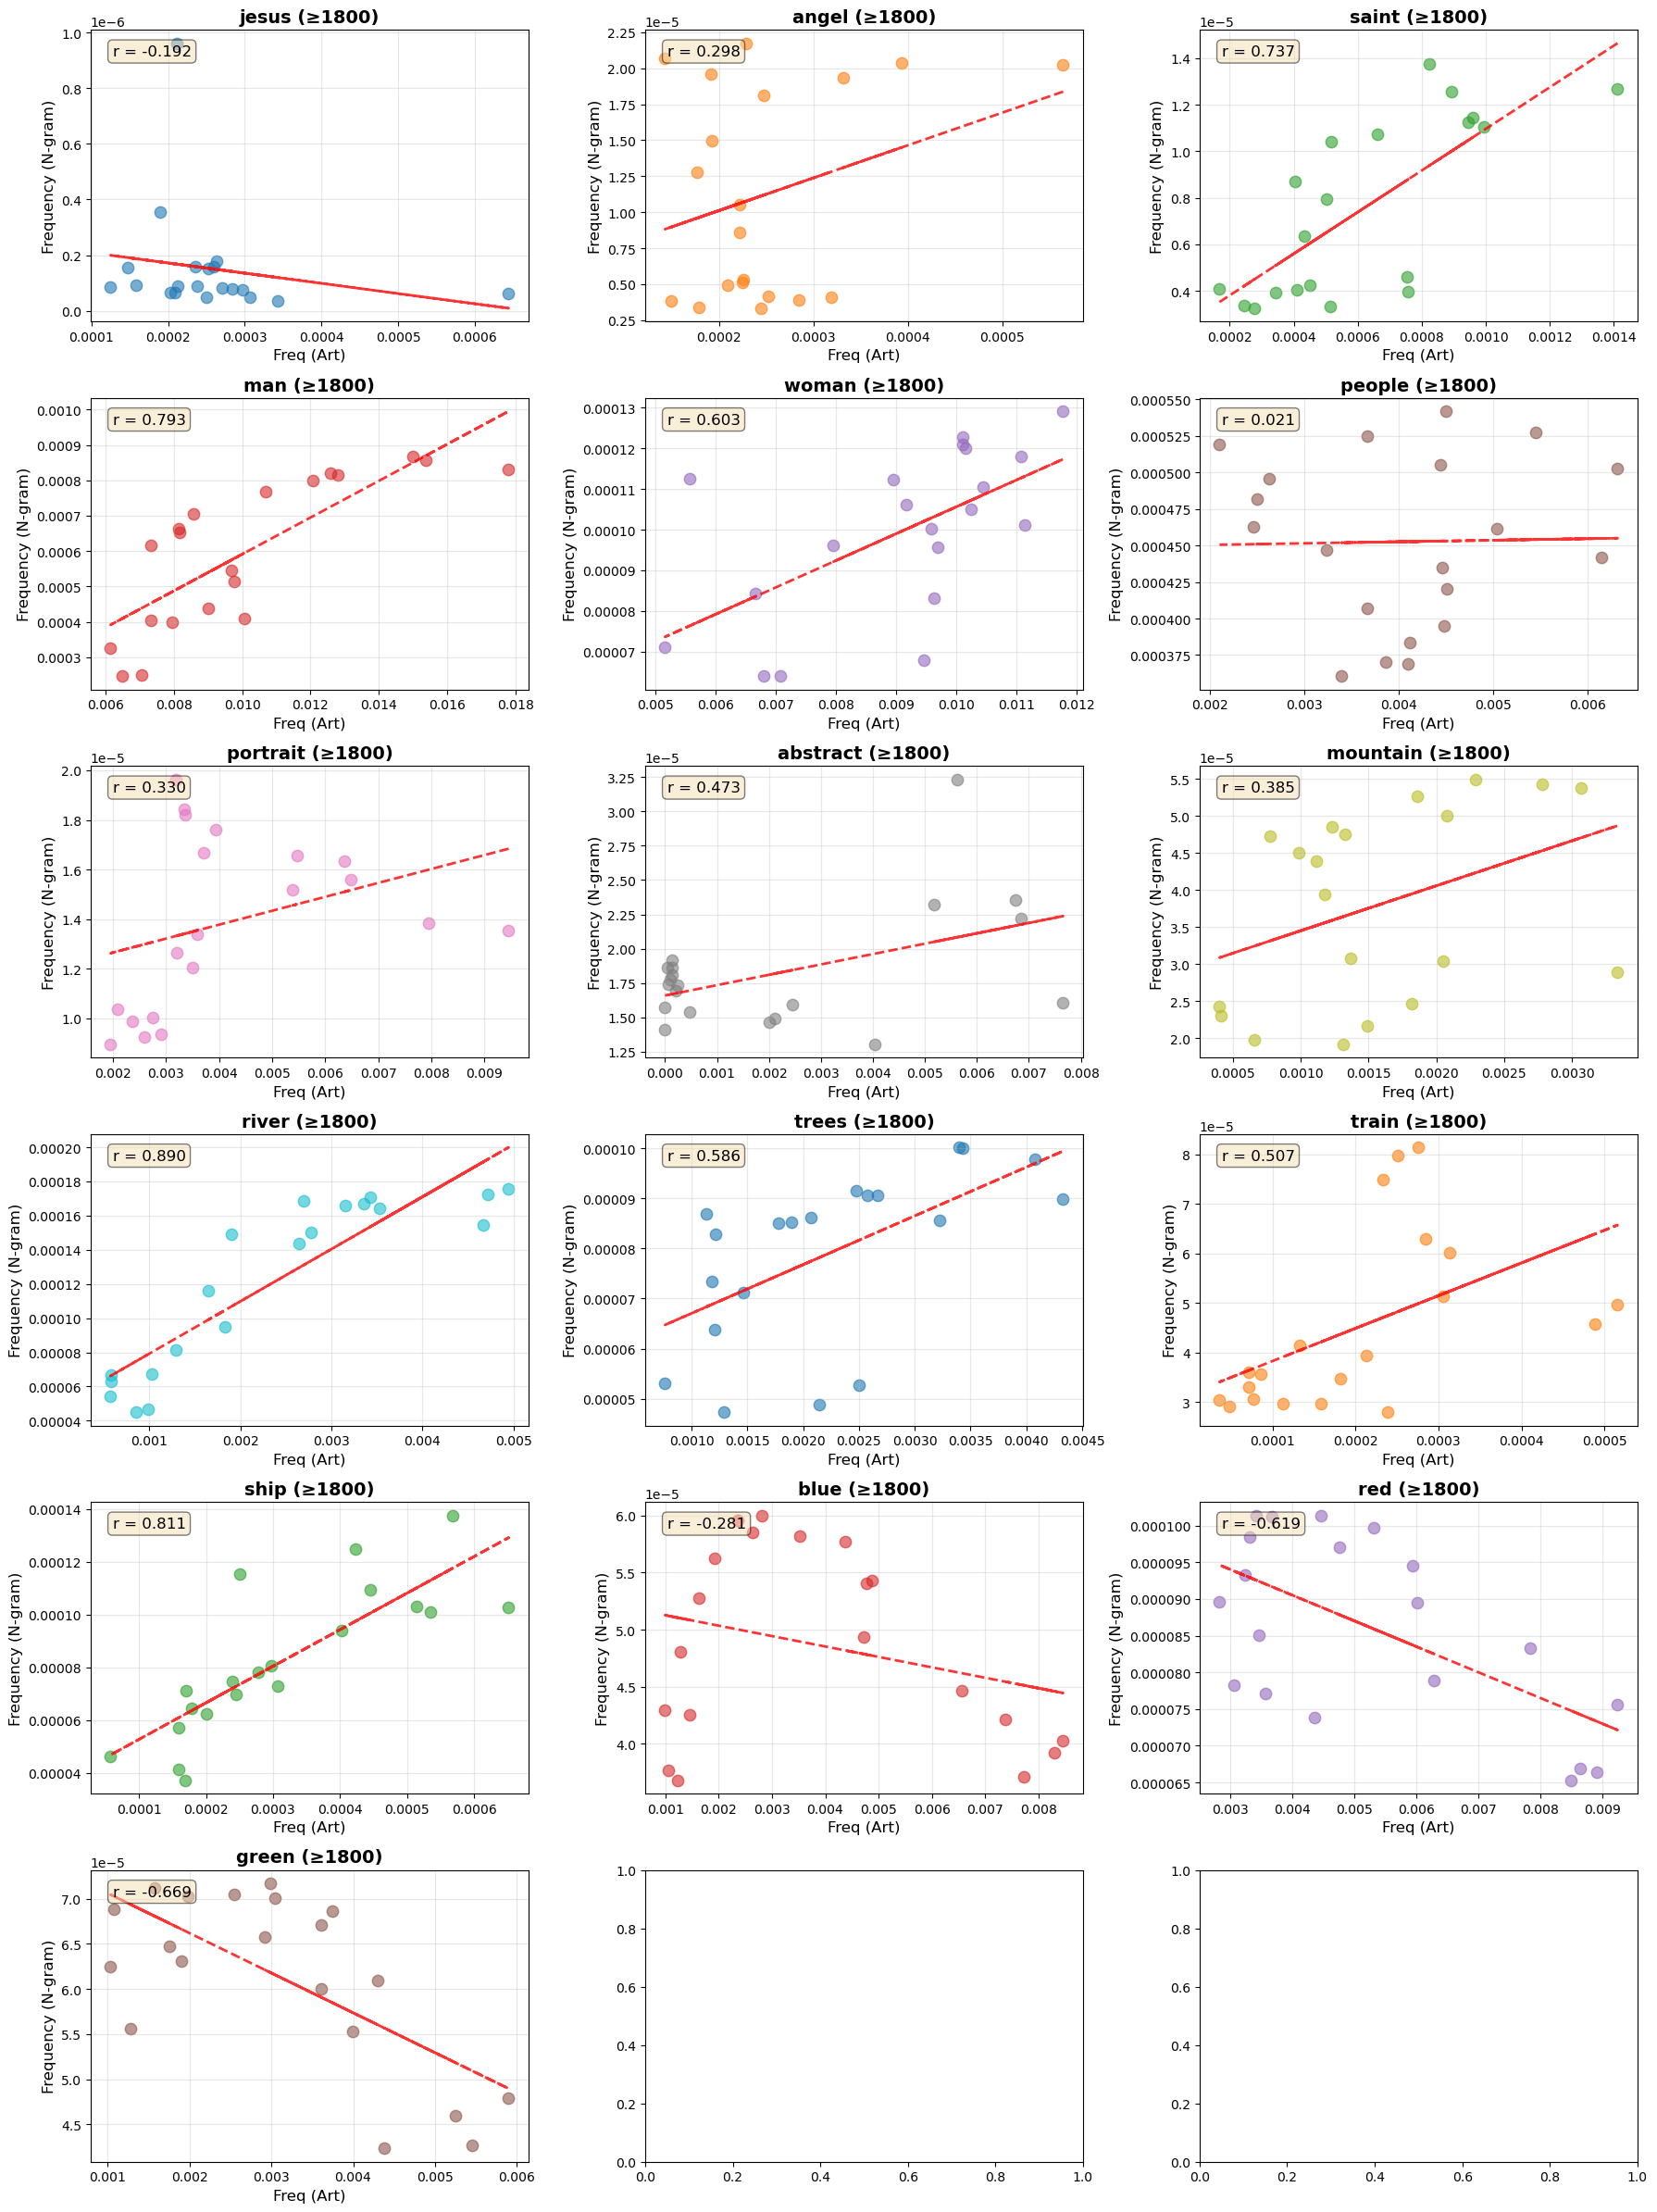

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 모든 단어 가져오기
all_words = df['ngram'].unique()

# 그리드 설정 (6x3 = 18개)
fig, axes = plt.subplots(6, 3, figsize=(18, 24))
axes = axes.reshape(-1)

for idx, word in enumerate(all_words):
    word_data = df_freq_merged[df_freq_merged['ngram'] == word].copy()
    word_data = word_data.sort_values('decade')
    
    # 1800년 이후 데이터만 필터링
    word_data = word_data[word_data['decade'] >= 1800]
    
    ax = axes[idx]
    
    # Scatter plot
    ax.scatter(word_data['Freq'], word_data['frequency'], 
               alpha=0.6, s=80, color=f'C{idx % 10}')
    
    # 추세선 추가 (선택사항)
    if len(word_data) > 1:  # 데이터가 2개 이상일 때만 추세선
        z = np.polyfit(word_data['Freq'], word_data['frequency'], 1)
        p = np.poly1d(z)
        ax.plot(word_data['Freq'], p(word_data['Freq']), 
                "r--", alpha=0.8, linewidth=2)
    
    # 상관계수 표시
    if len(word_data) > 1:  # 데이터가 2개 이상일 때만 상관계수
        corr = word_data['Freq'].corr(word_data['frequency'])
        ax.text(0.05, 0.95, f'r = {corr:.3f}', 
                transform=ax.transAxes, 
                fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Freq (Art)', fontsize=12)
    ax.set_ylabel('Frequency (N-gram)', fontsize=12)
    ax.set_title(f'{word} (≥1800)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig("./Fig03_with_ngram_scatter_1800.png", dpi=300)
plt.savefig("./Fig03_with_ngram_scatter_1800.pdf")
plt.show()

In [20]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# 단어별로 그룹화하여 상관계수 계산
correlations = []

for word in df['ngram'].unique():
    word_data = df_freq_merged[df_freq_merged['ngram'] == word].copy()
    
    # decade 기준으로 정렬
    word_data = word_data.sort_values('decade')
    word_data = word_data[word_data['decade'] >= 1800]

    
    # Pearson 상관계수
    pearson_corr, pearson_pval = pearsonr(word_data['Freq'], word_data['frequency'])
    
    # Spearman 상관계수 (순위 기반)
    spearman_corr, spearman_pval = spearmanr(word_data['Freq'], word_data['frequency'])
    
    correlations.append({
        'word': word,
        'pearson_corr': pearson_corr,
        'pearson_pval': pearson_pval,
        'spearman_corr': spearman_corr,
        'spearman_pval': spearman_pval,
        'n_points': len(word_data)
    })

corr_df = pd.DataFrame(correlations)
corr_df = corr_df.sort_values('pearson_corr', ascending=False)

corr_df

,word,pearson_corr,pearson_pval,spearman_corr,spearman_pval,n_points
9,river,0.890350,1.452572e-07,0.923308,6.582911e-09,20
12,ship,0.810530,1.468497e-05,0.867669,7.239120e-07,20
3,man,0.793258,3.009269e-05,0.861654,1.055525e-06,20
2,saint,0.736638,2.121102e-04,0.759398,1.030315e-04,20
4,woman,0.603468,4.845418e-03,0.583459,6.922691e-03,20
10,trees,0.585630,6.666963e-03,0.648120,1.998714e-03,20
11,train,0.506859,2.255965e-02,0.657143,1.643088e-03,20
7,abstract,0.472837,3.525188e-02,0.228657,3.322100e-01,20
8,mountain,0.384621,9.404135e-02,0.484211,3.050849e-02,20
6,portrait,0.330216,1.550449e-01,0.538346,1.433546e-02,20


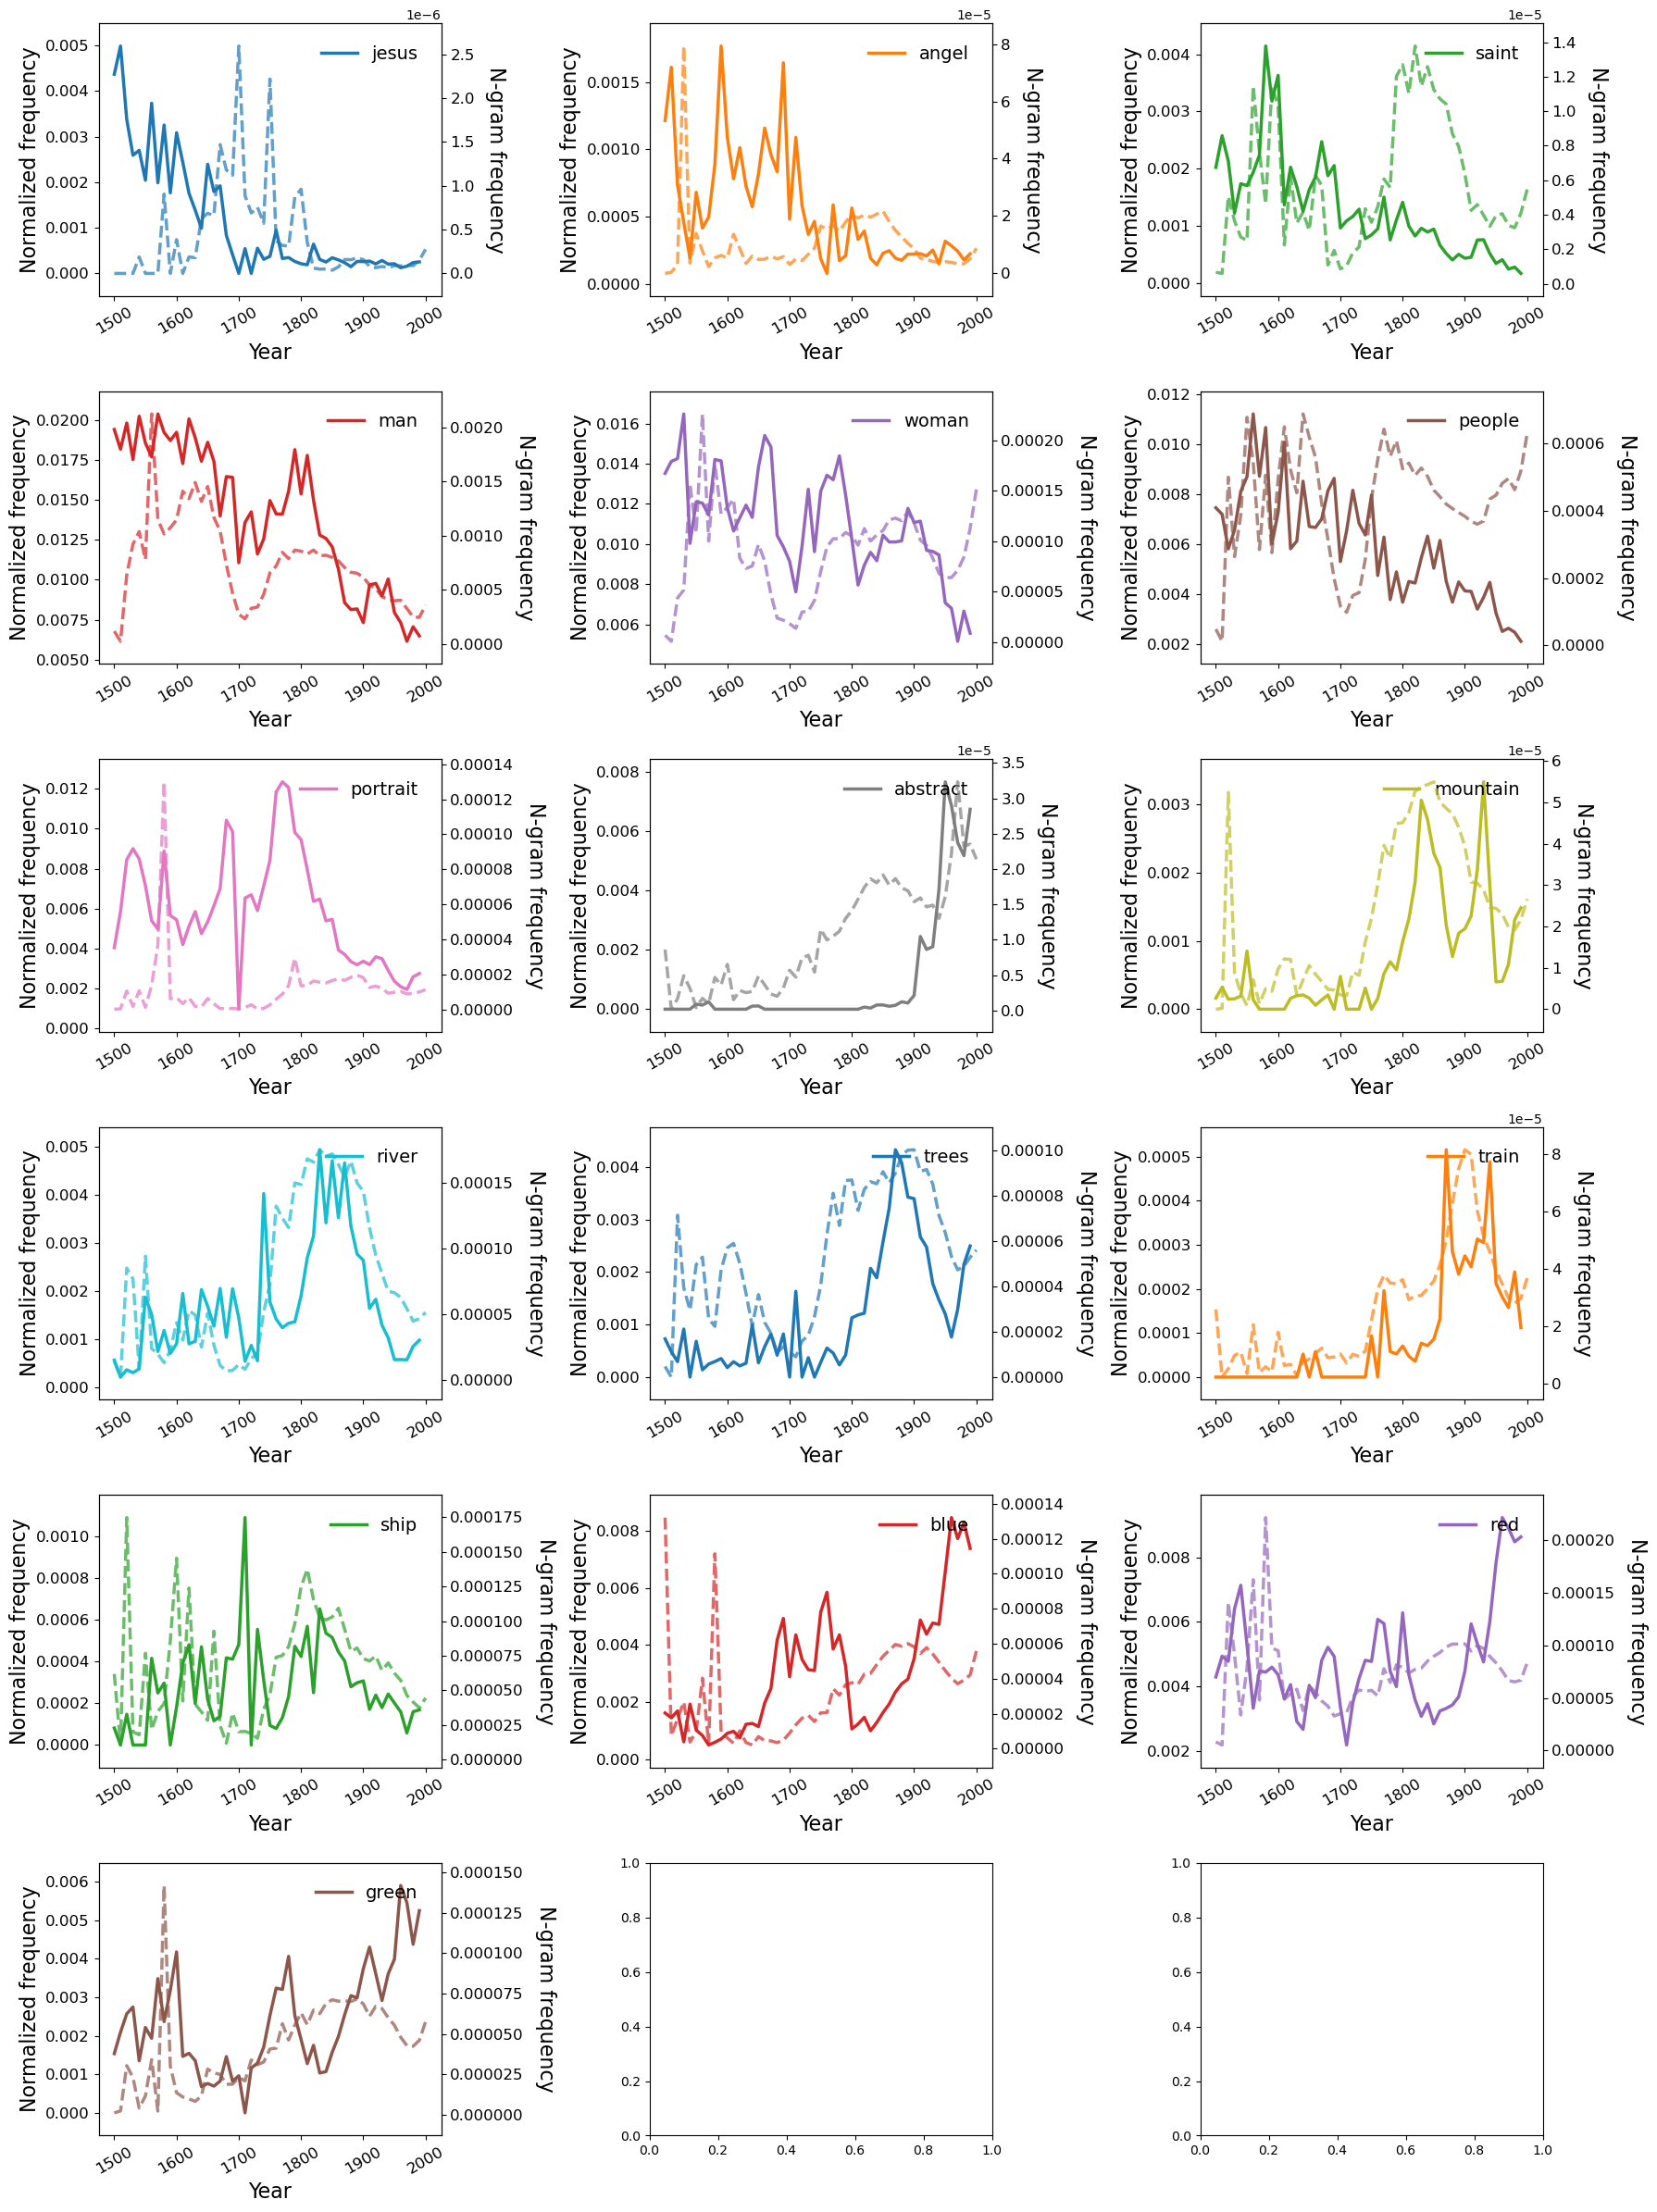

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 모든 단어를 하나의 리스트로 flatten
all_words = [word for sublist in words_zip for word in sublist]

# 6x3 그리드 생성 (총 18개 단어)
fig, ax = plt.subplots(6, 3, figsize=(18, 24))
ax = ax.reshape(-1)

for idx, word in enumerate(all_words):
    # 두 번째 y축 생성
    ax2 = ax[idx].twinx()
    
    # 단어별로 동일한 색상 사용
    color = f'C{idx % 10}'
    
    # 원본 데이터 (실선)
    ax[idx].plot(df_norm[df_norm.columns.difference(['slope', 'word'])].loc[word2idx[word]], 
                 label=f'{word}', 
                 color=color, 
                 linestyle='-',
                 linewidth=2.5)
    
    # n-gram 데이터 (파선)
    ngram_data = df_mean_freq_decade[df_mean_freq_decade['ngram'] == word]
    if not ngram_data.empty:
        ax2.plot(ngram_data['decade'], 
                ngram_data['frequency'], 
                color=color, 
                linestyle='--',
                linewidth=2.5,
                alpha=0.7)
    
    # 범례 설정
    ax[idx].legend(loc='upper right', bbox_to_anchor=(0.98, 0.98),
                   fontsize=14, frameon=False)
    
    # 왼쪽 y축 설정 (원본 데이터)
    ax[idx].set_xlabel('Year', fontsize=16)
    ax[idx].set_ylabel('Normalized frequency', fontsize=16)
    
    # y축 자동 스케일링
    y_data = df_norm[df_norm.columns.difference(['slope', 'word'])].loc[word2idx[word]].values
    y_min, y_max = y_data.min(), y_data.max()
    y_range = y_max - y_min
    ax[idx].set_ylim(y_min - y_range*0.1, y_max + y_range*0.1)
    
    # 오른쪽 y축 설정 (n-gram 데이터)
    ax2.set_ylabel('N-gram frequency', fontsize=16, rotation=270, labelpad=25)
    
    # n-gram 데이터의 min/max 기준으로 y축 설정
    if not ngram_data.empty:
        ngram_min = ngram_data['frequency'].min()
        ngram_max = ngram_data['frequency'].max()
        ngram_range = ngram_max - ngram_min
        if ngram_range > 0:
            ax2.set_ylim(ngram_min - ngram_range*0.1, ngram_max + ngram_range*0.1)
    
    # x축 설정
    ax[idx].set_xticks([1500+i*100 for i in range(6)])
    ax[idx].tick_params(axis='x', labelsize=12, rotation=30)
    ax[idx].tick_params(axis='y', labelsize=12)
    ax2.tick_params(axis='y', labelsize=12)

plt.tight_layout()
#plt.savefig('/home/jinny/projects/Art-history/Art-history/graph/figure03_individual.svg',bbox_inches='tight',transparent=True,dpi=600)
plt.show()

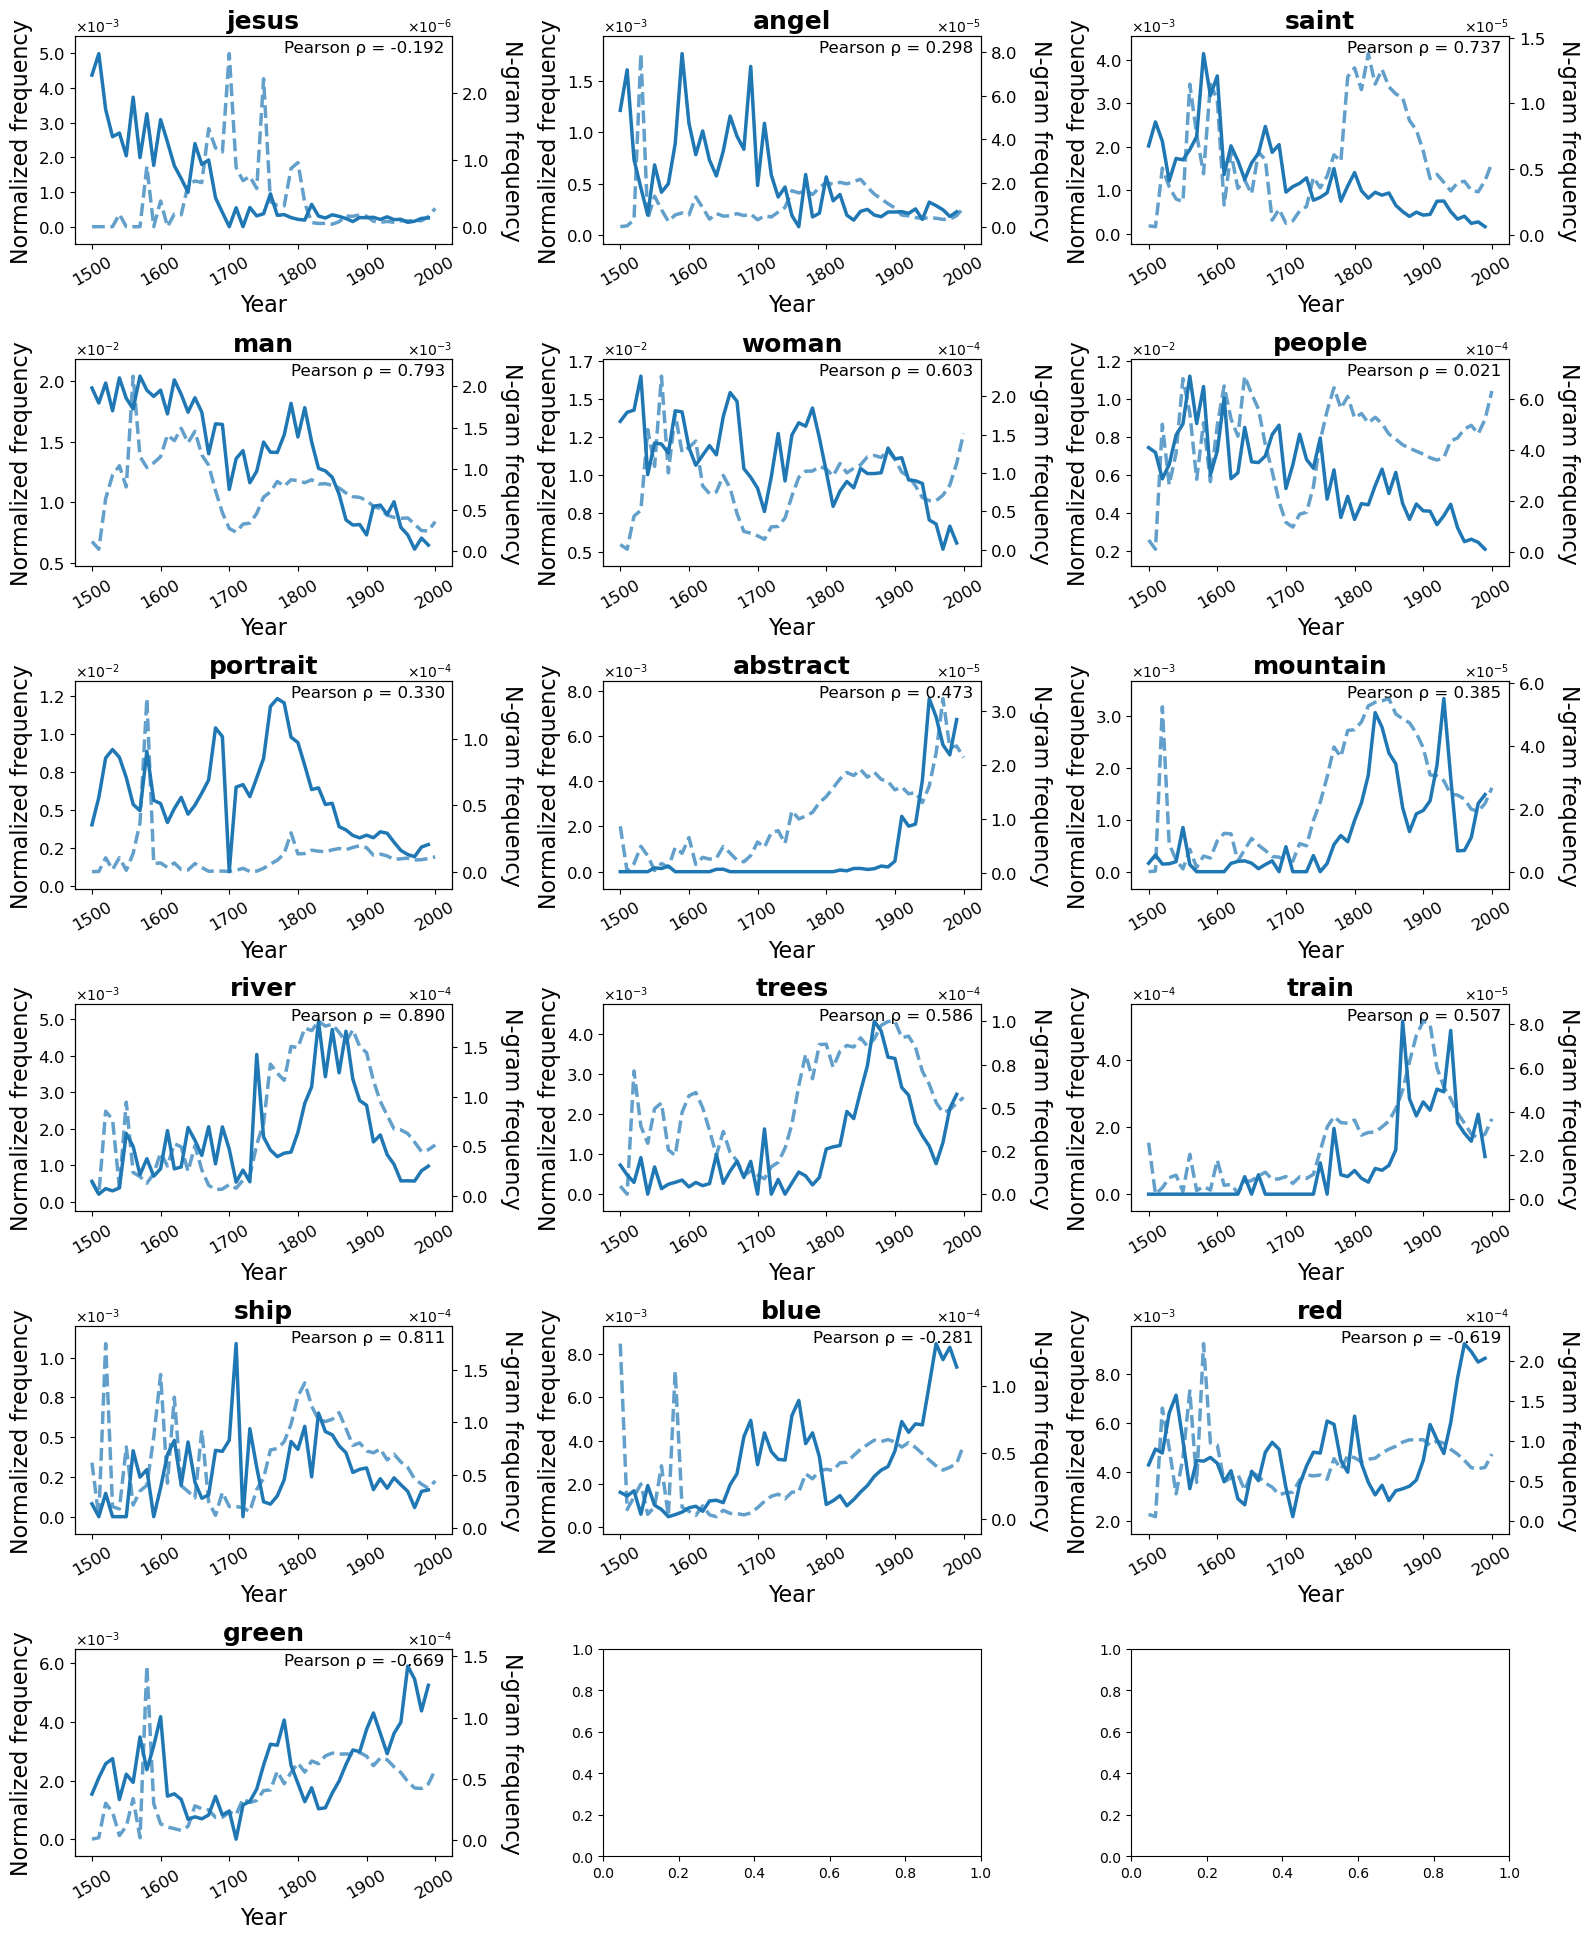

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter, FuncFormatter

# 모든 단어를 하나의 리스트로 flatten
all_words = [word for sublist in words_zip for word in sublist]

# 6x3 그리드 생성 (총 18개 단어) - 높이를 10% 줄임
fig, ax = plt.subplots(6, 3, figsize=(16, 19.5))  # 24 * 0.9 = 21.6
ax = ax.reshape(-1)

for idx, word in enumerate(all_words):
    # 두 번째 y축 생성
    ax2 = ax[idx].twinx()
    
    # 모든 그래프에 동일한 색상 사용
    color = 'C0'  # matplotlib 기본 파란색
    
    # 원본 데이터 (실선)
    ax[idx].plot(df_norm[df_norm.columns.difference(['slope', 'word'])].loc[word2idx[word]], 
                 color=color, 
                 linestyle='-',
                 linewidth=2.5)
    
    # n-gram 데이터 (파선)
    ngram_data = df_mean_freq_decade[df_mean_freq_decade['ngram'] == word]
    if not ngram_data.empty:
        ax2.plot(ngram_data['decade'], 
                ngram_data['frequency'], 
                color=color, 
                linestyle='--',
                linewidth=2.5,
                alpha=0.7)
    
    # Pearson correlation 값 가져오기
    pearson_corr = corr_df[corr_df['word'] == word]['pearson_corr'].values
    if len(pearson_corr) > 0:
        corr_text = f'Pearson ρ = {pearson_corr[0]:.3f}'
    else:
        corr_text = 'Pearson ρ = N/A'
    
    # 타이틀로 단어명 표시
    ax[idx].set_title(f'{word}', fontsize=18, fontweight='bold')
    
    # Pearson correlation 표시
    ax[idx].text(0.98, 0.98, corr_text,
                transform=ax[idx].transAxes,
                fontsize=12,
                verticalalignment='top',
                horizontalalignment='right')
    
    # 과학적 표기법 설정 (×10ⁿ 형태, 소수점 1자리)
    class CustomFormatter(ScalarFormatter):
        def _set_format(self):
            self.format = '%.1f'
    
    formatter = CustomFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))
    
    ax[idx].yaxis.set_major_formatter(formatter)
    ax[idx].ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
    
    formatter2 = CustomFormatter(useMathText=True)
    formatter2.set_powerlimits((0, 0))
    ax2.yaxis.set_major_formatter(formatter2)
    ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
    
    # 왼쪽 y축 설정 (원본 데이터)
    ax[idx].set_xlabel('Year', fontsize=16)
    ax[idx].set_ylabel('Normalized frequency', fontsize=16)
    
    # y축 자동 스케일링
    y_data = df_norm[df_norm.columns.difference(['slope', 'word'])].loc[word2idx[word]].values
    y_min, y_max = y_data.min(), y_data.max()
    y_range = y_max - y_min
    ax[idx].set_ylim(y_min - y_range*0.1, y_max + y_range*0.1)
    
    # 오른쪽 y축 설정 (n-gram 데이터)
    ax2.set_ylabel('N-gram frequency', fontsize=16, rotation=270, labelpad=25)
    
    # n-gram 데이터의 min/max 기준으로 y축 설정
    if not ngram_data.empty:
        ngram_min = ngram_data['frequency'].min()
        ngram_max = ngram_data['frequency'].max()
        ngram_range = ngram_max - ngram_min
        if ngram_range > 0:
            ax2.set_ylim(ngram_min - ngram_range*0.1, ngram_max + ngram_range*0.1)
    
    # x축 설정
    ax[idx].set_xticks([1500+i*100 for i in range(6)])
    ax[idx].tick_params(axis='x', labelsize=12, rotation=30)
    ax[idx].tick_params(axis='y', labelsize=12)
    ax2.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.savefig('./Fig03_with_ngram_expanded.png', bbox_inches='tight', dpi=300)
plt.savefig('./Fig03_with_ngram_expanded.pdf', bbox_inches='tight')
plt.show()